# Lecture 5, Coupling vegetation and hydrology in a zero-dimensional climate model

This lecture extends the ice-albedo model of Lecture 4 by introducing a biosphere and a hydrological cycle, following Svirezhev and von Bloh (1998). The model builds on two earlier papers by the same authors. Svirezhev and von Bloh (1996) coupled a temperature equation to a vegetation equation and identified up to two stable equilibria, a "dead" planet without vegetation and a "living" planet with vegetation. Svirezhev and von Bloh (1997) added a global carbon cycle as a third state variable and showed that the living branch itself bifurcates into a "cold" and a "hot" vegetated state, giving up to three stable equilibria. Svirezhev and von Bloh (1998), the paper treated here, adds a hydrological cycle on top of this carbon-cycle model: cloudiness and a two-layer albedo scheme are introduced on the climatic side, and the productivity of the biosphere is made to depend on soil moisture on the biotic side.

The notebook introduces each new term before it is used in an equation, and points back to the corresponding piece of the energy balance model from Lecture 2 and Lecture 4 wherever one exists, so that the new model can be read as an extension of that earlier model rather than as an unrelated system. Several entries in the parameter table of the original paper are not fully legible in the scanned version used here, so the parameter values below are chosen to reproduce the reported bifurcation structure rather than to match every published figure to the last decimal.

In [ ]:
# Google Colab setup: install the packages this notebook uses.
# Runs only on Colab; skipped in Binder or a local Jupyter install.
import sys
if "google.colab" in sys.modules:
    %pip install -q numpy pandas matplotlib scipy xarray netcdf4 pydap ipywidgets


## 1) Review: the energy balance model of Lectures 2 and 3

Lecture 2 introduced the zero-dimensional energy balance equation

$$C\frac{dT}{dt} = \frac{(1-\alpha)S}{4} - (A - BT) + a\ln\left(\frac{[\text{CO}_2]}{[\text{CO}_2]_{PI}}\right),$$

where $C$ is the heat capacity of the climate system, $S$ is the solar constant, $\alpha$ is a constant planetary albedo, and outgoing thermal radiation is represented by the linear fit $A - BT$. Lecture 3 kept this same equation but let the albedo depend on temperature, $\alpha(T)$, stepping from an ice value to an ocean value over a narrow temperature range, which is what produced the ice-albedo feedback and the resulting cold and warm stable states.

The model in this lecture keeps the same left-hand side, a heat capacity multiplying $dT/dt$, and the same idea of albedo depending on the state of the planet. Three things change on the right-hand side, matching the three additional processes this paper wants to represent.

1. Outgoing thermal radiation is written as full Stefan-Boltzmann radiation, $\sigma_{eff} T^4$, rather than the linear fit $A - BT$, because the paper wants the atmosphere's greenhouse effect to depend explicitly on how much carbon and water vapour it holds, and a fixed linear fit cannot represent that dependence.
2. Albedo depends not just on temperature but on how much vegetation is present and how much moisture the soil holds, because a vegetated, moist surface reflects sunlight differently from a bare, dry one.
3. Two further balance equations are added, one for the carbon held in vegetation and one for atmospheric water, because the whole point of this lecture is to let the biosphere and the hydrological cycle feed back onto temperature rather than being fixed inputs to it.

Because $A$ and $B$ already denote the outgoing-radiation fit constants in Lectures 2 and 4, and the paper this lecture follows uses the same two letters for something else entirely, namely the total carbon and total water available to the system, this reuse is worth flagging once and then setting aside: $A$ and $B$ from here on always mean total carbon and total water, following Svirezhev and von Bloh's own notation, and the linear fit $A - BT$ does not reappear in this lecture. The heat capacity keeps the symbol $C$ used in Lectures 2 and 4.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib

## 2) Three state variables, two conservation laws

Before writing any new equation, it helps to name the three quantities this lecture tracks and see why there are only three of them rather than five.

The climate is described by the average surface temperature $T$, exactly as before. The biosphere is described by the carbon content of vegetation $N$. The atmosphere holds a total amount of carbon $C_a$ and a water-vapour content $W_a$, both written with the subscript "a" for atmosphere; the soil beneath holds a corresponding water content $W_s$.

This looks like five state variables, $T$, $N$, $C_a$, $W_a$, $W_s$, but two conservation laws cut it down to three. With anthropogenic emissions neglected, the total carbon in the system is conserved,

$$C_a(t) + N(t) = A = \text{const},$$

and, since the planet is assumed to have no ocean, the total water in the system is conserved as well,

$$W_a(t) + W_s(t) = B = \text{const}.$$

These two relations are used to eliminate $C_a$ and $W_s$ throughout, writing $C_a = A - N$ and $W_s = B - W_a$ wherever they are needed. What remains to integrate forward in time are three coupled equations, for $T$, $N$, and $W_a$, and $A$ and $B$, together with the maximum productivity $P_{max}$ introduced in Section 5, are the bifurcation parameters that control how many stable states this system has.

## 3) The temperature equation

### 3.1) Two greenhouse functions, in place of the linear OTR fit

Before writing the temperature equation, two new functions need defining, because they replace the single linear fit $A - BT$ used in Lectures 2 and 4. The idea is that the atmosphere's effective emissivity is reduced separately by the carbon it holds and by the water vapour it holds, so two saturating functions are introduced, one per greenhouse agent, following Mokhov and Petoukhov (1978):

$$\varphi_C(C_a) = 1 - C_a\frac{1-\varphi_C^{\infty}}{k_C + C_a}, \qquad \varphi_W(W_a) = \frac{1 + A_W B_W W_a^{\,b_W}}{1 + B_W W_a^{\,b_W}}.$$

Both functions equal 1 when their argument is zero, meaning no greenhouse effect, and decay towards a saturation level as $C_a$ or $W_a$ grows large, meaning the greenhouse effect strengthens but eventually stops responding to further increases. Together they set the effective emissivity, $\sigma_{eff} = \sigma\,\varphi_C(C_a)\,\varphi_W(W_a)$, which stands in for the fixed coefficients $A$ and $B$ of the linear OTR fit.

### 3.2) Cloudiness, needed for both radiation and albedo

A second new quantity, cloudiness $n$, is needed before the temperature equation can be written, because it appears in the radiative loss term below and will reappear in the albedo of Section 4. Cloudiness is diagnosed from relative humidity $q = W_a / W_a^{*}(T)$, where $W_a^{*}(T)$ is the saturated water-vapour concentration, following the Clausius-Clapeyron relation, and $n$ follows Smagorinsky (1960):

$$n = \begin{cases} 2q - 1, & 0.5 \le q \le 1 \\ 0, & 0 \le q < 0.5. \end{cases}$$

In words, the atmosphere is taken to be cloud-free below 50% relative humidity, and cloudiness rises linearly to 1 as saturation is approached.

### 3.3) The temperature equation itself

With $\varphi_C$, $\varphi_W$, and $n$ defined, the temperature equation, taken from Petoukhov and Ganopolski (1994), can now be written in the same form as the Lecture 2 equation, heat capacity times $dT/dt$ on the left, absorbed minus outgoing radiation on the right:

$$C\frac{dT}{dt} = S(1-\alpha) - \sigma_{eff} T^4 - k_W W_a n,$$

where $S$ is the solar radiation, $\alpha$ is the surface albedo defined in Section 4, and $k_W$ is the latent heat of evaporation, weighting a small additional cooling term proportional to cloudy atmospheric water content.

In [ ]:
S        = 340.0     # solar radiation, W/m2
sigma    = 5.67e-8   # Stefan-Boltzmann constant
kW       = 0.4       # latent heat weighting
C_heat   = 6.0        # surface heat capacity, year-scaled

phiC_inf = 0.42       # saturation level of the carbon greenhouse function
kC       = 750.0      # half-saturation, Gt

AW, BW, bw = 0.50, 0.30, 0.50   # water-vapour greenhouse function parameters


def phiC(Ca):
    """Greenhouse function of atmospheric carbon, Mokhov and Petoukhov (1978)."""
    return 1.0 - Ca * (1.0 - phiC_inf) / (kC + Ca)


def phiW(Wa):
    """Greenhouse function of atmospheric water vapour."""
    x = max(Wa, 1e-6) ** bw
    return (1.0 + AW * BW * x) / (1.0 + BW * x)


def Wa_sat(T):
    """Saturated water-vapour concentration, Clausius-Clapeyron approximation."""
    return np.exp(17.638 * T / (T + 243.4))


def cloudiness(T, Wa):
    """Cloudiness as a function of relative humidity, Smagorinsky (1960)."""
    q = np.clip(Wa / Wa_sat(T), 0.0, 1.0)
    return np.clip(2.0 * q - 1.0, 0.0, 1.0)

## 4) Albedo: from a step function to a vegetated, snow-covered surface

Lecture 4 already made albedo depend on the state of the planet, stepping between an ice value and an ocean value as temperature crossed a narrow range. This section builds a more detailed albedo, still state-dependent, but now also sensitive to how much vegetation is present and how moist the soil is, following Svirezhev and von Bloh rather than the step-like ice line of Budyko (1969).

Three new quantities need defining before the albedo itself can be written down, each answering a specific question about the surface.

**How much of the land is bare, rather than vegetated?** This is given by a share of land not covered by vegetation, $\lambda(N)$, a decreasing function of vegetation carbon $N$: the more vegetation, the smaller the bare fraction.

$$\lambda(N) = 1 - \frac{N}{k_a + N}.$$

**How much of the land is under snow?** This is given by a share of land covered by snow, $f_{sn}(T)$, a smooth, piecewise-linear function of temperature that replaces the harder ice-line threshold of Lecture 4 and of Budyko (1969):

$$f_{sn}(T) = \begin{cases} 1, & T < -15^{\circ}\text{C} \\ 1 - \dfrac{T+15}{30}, & -15^{\circ}\text{C} \le T < 15^{\circ}\text{C} \\ 0, & T \ge 15^{\circ}\text{C}. \end{cases}$$

**How does bare-soil albedo depend on moisture?** Dry soil reflects more than wet soil, so a bare-soil albedo function $f_{bs}$ scales a reference dry-soil albedo down as relative soil moisture $W_s/W_s^{*}$ increases towards saturation.

With $\lambda(N)$, $f_{sn}(T)$, and $f_{bs}$ in hand, the surface albedo is built up in two layers: first a snow-free surface albedo mixing bare soil and vegetation, then a blend of that surface with snow, and finally a blend of the resulting surface albedo with a cloud-layer albedo, using the same cloudiness $n$ already defined in Section 3.2,

$$\alpha_{surf} = \big[\lambda(N)\,\alpha_{bs} + (1-\lambda(N))\,\alpha_{veg}\big](1-f_{sn}) + \alpha_{sn} f_{sn}, \qquad \alpha = 0.1 + 0.4n + \alpha_{surf}(0.81 - 0.56n).$$

In [ ]:
aveg, abs0, asn = 0.10, 0.40, 0.70   # albedo of vegetation, dry bare soil, snow
ka       = 600.0     # Gt, half-saturation of lambda(N)
fbs_star = 0.5        # asymptotic soil-albedo factor at saturation


def lam(N):
    """Share of land not covered by vegetation."""
    return 1.0 - N / (ka + N)


def fsn(T):
    """Share of land covered by snow."""
    if T < -15.0:
        return 1.0
    if T < 15.0:
        return 1.0 - (T + 15.0) / 30.0
    return 0.0


def fbs(frac):
    """Dependence of bare-soil albedo on relative soil moisture."""
    frac = np.clip(frac, 0.0, 1.0)
    return 1.0 - frac * (1.0 - fbs_star)


def albedo(T, N, Wa, Ws):
    n = cloudiness(T, Wa)
    l = lam(N)
    a_bs = abs0 * fbs(Ws / Ws_star)
    fsn_ = fsn(T)
    a_surf = (l * a_bs + (1 - l) * aveg) * (1 - fsn_) + asn * fsn_
    a = 0.1 + 0.4 * n + a_surf * (0.81 - 0.56 * n)
    return a, n

## 5) Vegetation: a new state variable, needing its own balance equation

Everything so far has adapted the climate side of Lecture 4's model. This section introduces the biosphere itself, which Lecture 4 did not have. Vegetation carbon $N$ needs its own balance equation because it is gained through productivity and lost through turnover, exactly as the temperature above is gained through absorbed radiation and lost through emitted radiation:

$$\frac{dN}{dt} = P - mN,$$

where $m = 1/\tau_N$ is the inverse residence time of living biomass and $P$ is the annual net productivity, still to be defined.

Before writing $P$, three limitation functions need naming, one per resource that can limit plant growth, following the Liebig principle as formalised by Keeling (1973): a function of temperature $g_T$, a function of available carbon $g_C$, a function of standing vegetation $g_N$, and a function of soil moisture $g_W$, combined multiplicatively so that growth is throttled by whichever resource is scarcest,

$$P = P_{max}\, g_T(T)\, g_C(C_a)\, g_N(N)\, g_W(W_s).$$

$g_C(A-N)$ is increasing in available carbon and $g_N(N)$ is increasing in existing vegetation up to a point, so Svirezhev and von Bloh merge the two into a single unimodal function of $N$ alone,

$$G_N(N) = g_C(A-N)\,g_N(N) = \frac{4N(A-N)}{A^2},$$

which is zero when there is no vegetation, zero again when vegetation has consumed essentially all the carbon in the system, and largest at $N = A/2$. $g_T$ and $g_W$ are each unimodal in the same way, nonzero only within a tolerance interval, $[T_1, T_2]$ for temperature and $[W_{s1}, W_{s2}]$ for soil moisture, and zero outside it, reflecting the fact that vegetation cannot grow if it is too cold, too hot, too dry, or too waterlogged.

In [ ]:
m_turn   = 0.03    # 1/year, vegetation turnover rate
T1, T2   = 5.0, 40.0        # deg C, thermal tolerance of vegetation
Ws1, Ws2 = 1.0, 18.0        # g/cm2, soil-moisture tolerance of vegetation
Ws_star  = 20.0             # g/cm2, saturated soil moisture
Pmax_default = 60.0         # Gt/yr, maximum productivity


def gT(T):
    return 4 * (T - T1) * (T2 - T) / (T2 - T1) ** 2 if T1 <= T <= T2 else 0.0


def GN(N, A):
    N = np.clip(N, 0.0, A)
    return 4 * N * (A - N) / A ** 2


def gW(Ws):
    return 4 * (Ws - Ws1) * (Ws2 - Ws) / (Ws2 - Ws1) ** 2 if Ws1 <= Ws <= Ws2 else 0.0


def productivity(T, N, Ws, A, Pmax):
    return Pmax * gT(T) * GN(N, A) * gW(Ws)

## 6) The hydrological cycle: closing the third balance equation

The last new balance equation needed is for atmospheric water $W_a$, and it is built the same way as the vegetation equation just introduced, as a gain term minus a loss term. Two new quantities need defining first.

**Precipitation** $H$ is taken to be proportional to the product of atmospheric water and cloudiness, $H = n_a W_a n$, using the same cloudiness $n$ defined in Section 3.2: a wetter, cloudier atmosphere rains more.

**Evaporation** $E$ combines two sources, weighted by the same land-cover fraction $\lambda(N)$ already defined in Section 4: physical evaporation of bare soil $E_{bs}$, driven by the local vapour deficit $W_a^{*}(T) - W_a$ and by relative soil moisture, and evapotranspiration by vegetation $E_{veg}$, taken proportional to the productivity $P$ defined in Section 5,

$$E = \lambda(N)\,E_{bs} + [1-\lambda(N)]\,E_{veg}, \qquad \frac{dW_a}{dt} = -H + E.$$

With $H$ and $E$ defined, all three right-hand sides, for $T$, $N$, and $W_a$, can be collected into a single function that a numerical solver can integrate forward in time.

In [ ]:
na_coef = 70.0    # 1/year, precipitation coefficient
nveg    = 0.03    # evapotranspiration coefficient


def rhs(t, y, A, B, Pmax):
    T, N, Wa = y
    N = np.clip(N, 1e-6, A - 1e-6)
    Wa = np.clip(Wa, 1e-6, B - 1e-6)
    Ws = B - Wa
    Ca = A - N

    a, n = albedo(T, N, Wa, Ws)
    sigma_eff = sigma * phiC(Ca) * phiW(Wa)
    TK = T + 273.15
    dT = (S * (1 - a) - sigma_eff * TK ** 4 - kW * Wa * n) / C_heat

    P = productivity(T, N, Ws, A, Pmax)
    dN = P - m_turn * N

    H = na_coef * Wa * n / B
    Ebs = max(Wa_sat(T) - Wa, 0.0) * Ws / Ws_star
    Eveg = nveg * P
    E = lam(N) * Ebs + (1 - lam(N)) * Eveg
    dWa = -H + E

    return [dT, dN, dWa]


def run(T0, N0, Wa0, A, B, t_end=300.0, Pmax=Pmax_default):
    return solve_ivp(rhs, [0, t_end], [T0, N0, Wa0], args=(A, B, Pmax),
                      method="Radau", dense_output=True, max_step=2.0)


def classify(T_final, N_final, N_tol=5.0):
    """Coarse label for a final state, used to count distinct equilibria."""
    if N_final < N_tol:
        return "dead"
    return "cold-living" if T_final < 5.0 else "warm-living" 

Because the water, temperature, and vegetation subsystems relax on very different time scales ($\tau_W \ll \tau_T \ll \tau_N$), the paper notes that the system must be integrated with a stiff solver; the same choice, an implicit Radau method, is made here.

### 6.1) A single pair of trajectories

The cell below starts two integrations from the same temperature but from different amounts of standing vegetation, at a fixed total carbon $A = 2200$ Gt. The two trajectories converge onto the same warm, vegetated equilibrium, though along different paths: the run that starts bare warms up first, before enough vegetation has grown to cool the planet back down through increased evapotranspiration and altered albedo, while the already-vegetated run relaxes to the equilibrium directly.

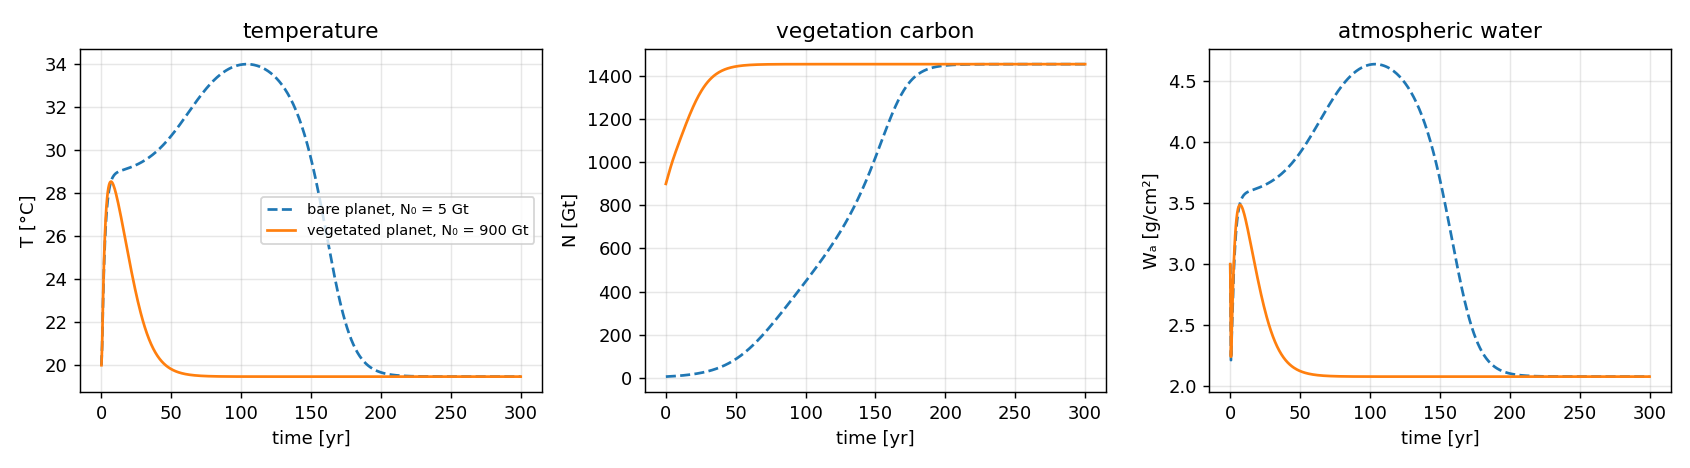

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
A_demo, B_demo = 2200.0, 15.0
t_plot = np.linspace(0, 300, 600)
for N0, style, label in [(5.0, "--", "bare planet, N0 = 5 Gt"),
                          (900.0, "-", "vegetated planet, N0 = 900 Gt")]:
    sol = run(T0=20.0, N0=N0, Wa0=3.0, A=A_demo, B=B_demo, t_end=300)
    Y = sol.sol(t_plot)
    axes[0].plot(t_plot, Y[0], style, label=label)
    axes[1].plot(t_plot, Y[1], style, label=label)
    axes[2].plot(t_plot, Y[2], style, label=label)
axes[0].set_ylabel("T [deg C]"); axes[0].set_xlabel("time [yr]"); axes[0].set_title("temperature")
axes[1].set_ylabel("N [Gt]"); axes[1].set_xlabel("time [yr]"); axes[1].set_title("vegetation carbon")
axes[2].set_ylabel("Wa [g/cm2]"); axes[2].set_xlabel("time [yr]"); axes[2].set_title("atmospheric water")
axes[0].legend(fontsize=8, loc="center right")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()

## 7) Basins of attraction depend on the total amount of carbon

Svirezhev and von Bloh show, in their Fig. 11, that the number and identity of stable equilibria change as the total carbon $A$ is increased at fixed total water $B$: at low $A$ only a cold, vegetation-free desert is stable; at intermediate $A$ the desert coexists with a vegetated state, so that the outcome depends on where the system starts; at high $A$ the desert disappears and only the vegetated state remains stable. This is the same kind of multistability seen in Lecture 4, where the bifurcation parameter was solar insolation rather than the total carbon budget; the cell below produces an analogous diagram by integrating a grid of initial temperatures and initial vegetation amounts to their final state, for four increasing values of $A$, and colouring each starting point by the equilibrium it reaches.

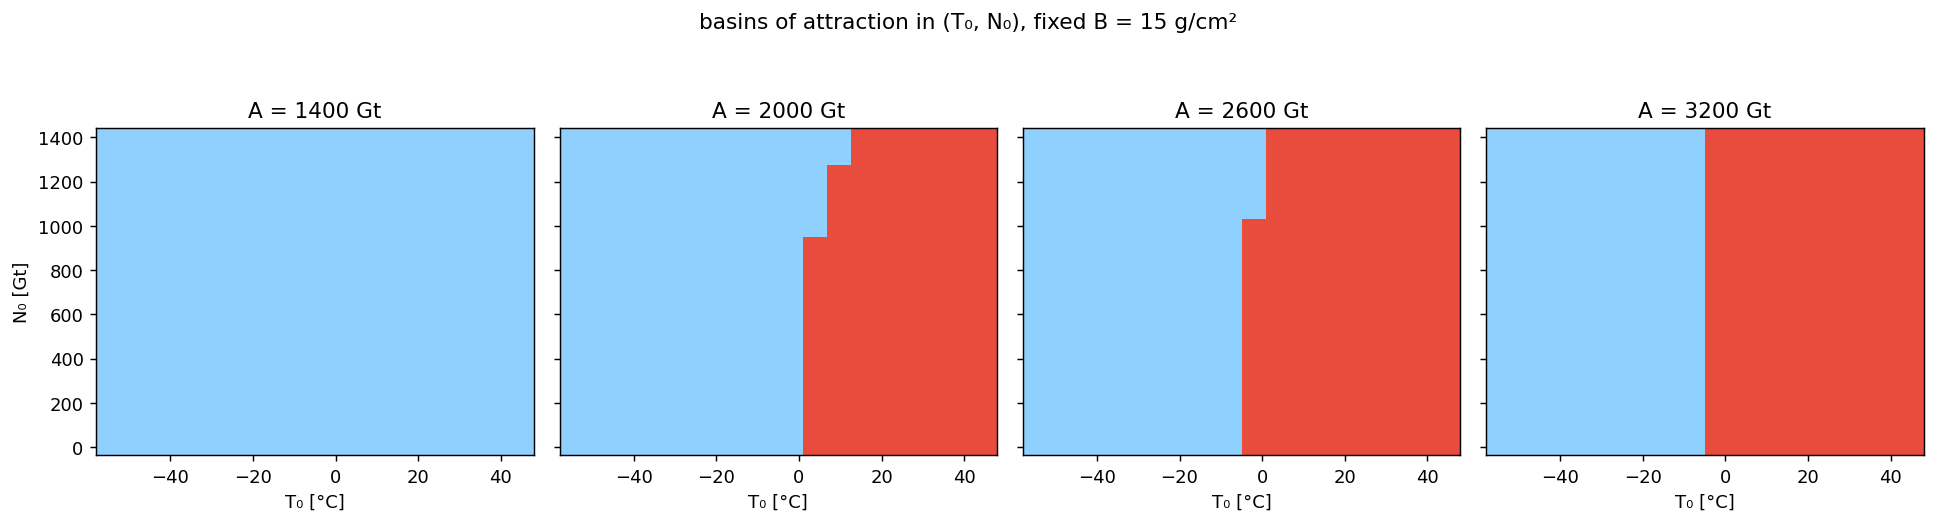

In [1]:
T0_grid = np.linspace(-55, 45, 18)
N0_grid = np.linspace(5, 1400, 18)
A_values = [1400.0, 2000.0, 2600.0, 3200.0]
B_fixed = 15.0

colour_map = {"dead": 0, "cold-living": 1, "warm-living": 2}
cmap = matplotlib.colors.ListedColormap(["#8fd0ff", "#2ecc71", "#e74c3c"])

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharex=True, sharey=True)
for ax, A in zip(axes, A_values):
    grid = np.zeros((len(N0_grid), len(T0_grid)))
    for i, N0 in enumerate(N0_grid):
        for j, T0 in enumerate(T0_grid):
            sol = run(T0=T0, N0=N0, Wa0=3.0, A=A, B=B_fixed, t_end=250)
            Tf, Nf, _ = sol.y[:, -1]
            grid[i, j] = colour_map[classify(Tf, Nf)]
    ax.pcolormesh(T0_grid, N0_grid, grid, cmap=cmap, vmin=0, vmax=2, shading="nearest")
    ax.set_title(f"A = {A:.0f} Gt")
    ax.set_xlabel("T0 [deg C]")
axes[0].set_ylabel("N0 [Gt]")
fig.suptitle(f"basins of attraction in (T0, N0), fixed B = {B_fixed:.0f} g/cm2", y=1.05)
fig.tight_layout()

The blue region marks initial conditions that relax to the cold, vegetation-free desert; the red region marks initial conditions that relax to a warm, vegetated state. At $A = 1400$ Gt the whole plane is blue: whatever vegetation the planet starts with, it dies out. Between $A = 2000$ Gt and $A = 2600$ Gt a red region appears at higher starting temperatures and vegetation amounts, so that the final state now depends on the initial condition, which is the numerical signature of bistability reported by Svirezhev and von Bloh for this parameter range. By $A = 3200$ Gt the red region has grown to cover essentially every starting vegetation amount at positive temperature, and the desert basin has shrunk to the cold half of the plane.

## 8) Counting stable states in the (A, B) plane

Svirezhev and von Bloh summarise the bifurcation structure of the full model in their Fig. 12, a map of the number of stable equilibria over the $(A, B)$ parameter plane, for fixed maximum productivity $P_{max}$, playing the same role that a map of equilibrium temperature against solar insolation played in Lecture 4. The cell below builds an analogous map: for each combination of $A$ and $B$ on a grid, four representative initial conditions are integrated to their final state, and the number of distinct final states reached is recorded.

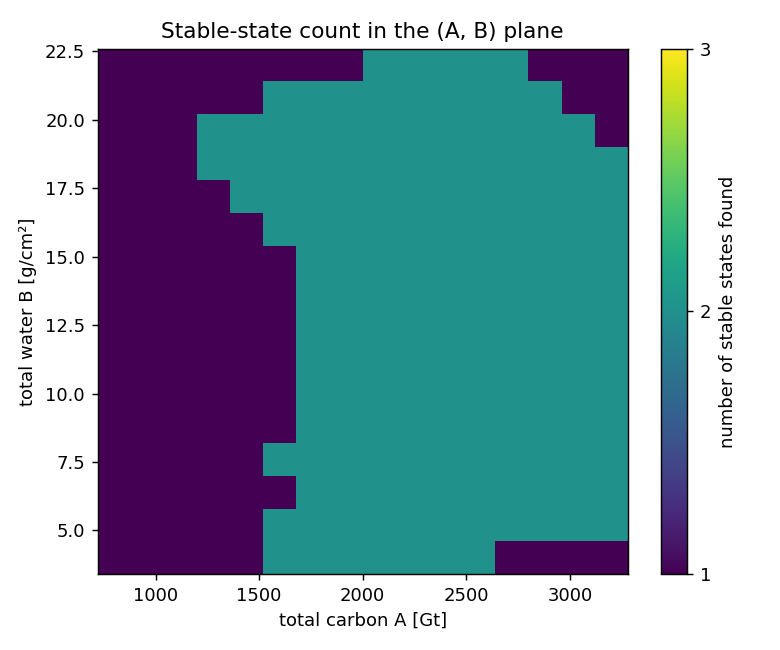

In [1]:
A_range = np.linspace(800, 3200, 16)
B_range = np.linspace(4, 22, 16)
initial_conditions = [(-40, 10, 2), (10, 10, 2), (20, 900, 3), (35, 1300, 5)]

n_states = np.zeros((len(B_range), len(A_range)))
for bi, B in enumerate(B_range):
    for ai, A in enumerate(A_range):
        labels = set()
        for T0, N0, Wa0 in initial_conditions:
            sol = run(T0=T0, N0=N0, Wa0=Wa0, A=A, B=B, t_end=250)
            Tf, Nf, _ = sol.y[:, -1]
            labels.add(classify(Tf, Nf))
        n_states[bi, ai] = len(labels)

fig, ax = plt.subplots(figsize=(6, 5))
pc = ax.pcolormesh(A_range, B_range, n_states, cmap="viridis", shading="nearest", vmin=1, vmax=3)
cbar = fig.colorbar(pc, ax=ax, ticks=[1, 2, 3])
cbar.set_label("number of stable states found")
ax.set_xlabel("total carbon A [Gt]")
ax.set_ylabel("total water B [g/cm2]")
ax.set_title("Stable-state count in the (A, B) plane")
fig.tight_layout()

A band of bistability separates a low-$A$ region in which only the desert is stable from a high-$A$ region in which only the vegetated state is stable, and this band shifts to somewhat higher $A$ as $B$ increases, since more available water raises the soil-moisture ceiling $g_W$ places on productivity. The reduced model used in this notebook does not reproduce the tristable region that Svirezhev and von Bloh report for a narrow band of $A$, in which a cold desert, a cold vegetated state, and a hot vegetated state are simultaneously stable; recovering that third branch would require refitting the greenhouse and albedo parameters more closely to the original table, which is left as an extension.

## 9) Summary

Starting from the two-variable climate-vegetation model of Svirezhev and von Bloh (1996), adding a carbon cycle (Svirezhev & von Bloh, 1997) and then a hydrological cycle (Svirezhev & von Bloh, 1998) turns a system with at most two stable climates into one whose number of stable climates depends on how much carbon and water the planet has to work with. The mechanism is the same ice-albedo-type positive feedback already met in Lecture 4, now joined by a second, biotic feedback: vegetation lowers albedo and raises evapotranspiration, so that a planet warm and wet enough to support plant growth tends to stay that way, while a planet that loses its vegetation loses this stabilising effect and can drift toward the cold, bare state. As in Lecture 4, the practical lesson is that a system with several stable states can respond to a small, gradual change in a parameter, here the total carbon or water budget, with an abrupt shift from one climate to another once a threshold is crossed.

### References

Budyko, M. I. (1969). The effect of solar radiation variations on the climate of earth. *Tellus, 21*, 611–619.

Keeling, C. D. (1973). The carbon dioxide cycle: Reservoir models to depict the exchange of atmospheric carbon dioxide with the oceans and land plants. In S. I. Rasool (Ed.), *Chemistry in the lower atmosphere* (pp. 251–329). Plenum Press.

Mokhov, I. I., & Petoukhov, V. K. (1978). *Parametrization of thermal radiation fluxes for climatic models* (Preprint No. 3, 34). Institute of Atmospheric Physics, USSR Academy of Sciences.

Petoukhov, V. K., & Ganopolski, A. V. (1994). *A set of climate models for integrated modelling of climate change impacts. Part II: A 2.5-dimensional dynamical climate model* (WP-94-39). IIASA.

Smagorinsky, J. (1960). On the dynamical prediction of large-scale condensation by numerical methods. In *Physics of precipitation* (Monograph No. 5, pp. 71–78). American Geophysical Union.

Svirezhev, Y. M., & von Bloh, W. (1996). A minimal model of interaction between climate and vegetation: Qualitative approach. *Ecological Modelling, 92*(1), 89–99.

Svirezhev, Y. M., & von Bloh, W. (1997). Climate, vegetation, and global carbon cycle: The simplest zero-dimensional model. *Ecological Modelling, 101*, 79–92.

Svirezhev, Y. M., & von Bloh, W. (1998). A zero-dimensional climate-vegetation model containing global carbon and hydrological cycle. *Ecological Modelling, 106*, 119–127.
